# 12 - Model Card
## Documentación estructurada del modelo en producción

**¿Qué es un Model Card?**  
Un Model Card (tarjeta de modelo) es un documento estándar que describe de forma 
transparente qué hace un modelo, con qué datos fue entrenado, qué tan bien funciona 
y para qué situaciones **no** debe usarse.

Fue propuesto por Google en 2018 y adoptado por Hugging Face, OpenAI y la mayoría 
de reguladores europeos como parte del AI Act.

**¿Por qué es obligatorio en MLOps profesional?**
- Los reguladores exigen saber **qué modelo** toma decisiones y por qué
- Los equipos de negocio necesitan conocer las **limitaciones** antes de desplegar
- Los auditores necesitan trazabilidad: ¿con qué datos, cuándo, con qué métricas?
- El Model Card **se genera automáticamente** desde los artefactos del pipeline

**Este notebook genera:**
- `experiments/model_card.json` — versión estructurada (para sistemas)
- `experiments/model_card.md`  — versión legible (para personas)

## Prerequisitos
- Haber ejecutado: `05_evaluacion_final.ipynb` y `07_monitoreo_reentrenamiento.ipynb`
- Requiere: `experiments/modelo_produccion.pkl`, `experiments/reporte_evaluacion.json`, `experiments/scaler.pkl`
- Este notebook genera: `experiments/model_card.json`, `experiments/model_card.md`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

EXP_DIR  = ROOT / 'experiments'
DATA_DIR = ROOT / 'data' / 'processed'
CFG_PATH = ROOT / 'config' / 'config.yaml'

print(f'ROOT    : {ROOT}')
print(f'EXP_DIR : {EXP_DIR}')

ROOT    : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
EXP_DIR : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments


## 1. Cargar Artefactos del Pipeline

El Model Card se genera **automáticamente** a partir de los artefactos 
que el pipeline ya produjo: modelo, scaler, configuración y reportes.

Así se garantiza que el documento siempre refleja la realidad del modelo 
en producción, sin edición manual.

In [2]:
# ── Configuración del proyecto ────────────────────────────────────────────
with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

# ── Modelo en producción ──────────────────────────────────────────────────
with open(EXP_DIR / 'modelo_produccion.pkl', 'rb') as f:
    modelo = pickle.load(f)

# ── Scaler ────────────────────────────────────────────────────────────────
with open(EXP_DIR / 'scaler.pkl', 'rb') as f:
    scaler_obj = pickle.load(f)
    scaler     = scaler_obj['scaler'] if isinstance(scaler_obj, dict) else scaler_obj
    columnas_scaler = scaler_obj['columnas'] if isinstance(scaler_obj, dict) else None

# ── Reporte de evaluación (NB05) ──────────────────────────────────────────
with open(EXP_DIR / 'reporte_evaluacion.json') as f:
    reporte_eval = json.load(f)

# ── Reporte de monitoreo (NB07) — opcional ───────────────────────────────
ruta_monitoreo = EXP_DIR / 'reporte_monitoreo.json'
reporte_monitor = json.load(open(ruta_monitoreo)) if ruta_monitoreo.exists() else {}

# ── Datos de test para análisis por subgrupos ────────────────────────────
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print('Artefactos cargados:')
print(f'  Modelo     : {type(modelo).__name__}')
print(f'  Scaler     : {type(scaler).__name__}')
print(f'  Eval RMSE  : {reporte_eval["metricas"]["rmse"]:.4f}')
print(f'  Eval R²    : {reporte_eval["metricas"]["r2"]:.4f}')
print(f'  Test shape : {test_df.shape}')
print(f'  Monitoreo  : {"disponible" if reporte_monitor else "no disponible"}')

Artefactos cargados:
  Modelo     : GradientBoostingRegressor
  Scaler     : StandardScaler
  Eval RMSE  : 0.4825
  Eval R²    : 0.8111
  Test shape : (3959, 14)
  Monitoreo  : disponible


## 2. Descripción del Modelo

La primera sección del Model Card responde la pregunta más básica:  
**¿Qué hace este modelo, para quién y cuándo fue creado?**

In [3]:
# ── Sección 1: Descripción general ───────────────────────────────────────
params_modelo = modelo.get_params()

seccion_modelo = {
    'nombre'             : cfg['proyecto']['nombre'],
    'version'            : cfg['proyecto']['version'],
    'fecha_generacion'   : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'tipo_problema'      : cfg['proyecto']['tipo_problema'],
    'algoritmo'          : cfg['modelo']['algoritmo'],
    'clase_python'       : type(modelo).__name__,
    'hiperparametros'    : {
        k: v for k, v in params_modelo.items()
        if k in ['n_estimators', 'learning_rate', 'max_depth', 'subsample', 'random_state']
    },
    'n_features'         : test_df.shape[1] - 1,
    'descripcion'        : cfg['proyecto']['descripcion'],
    'objetivo_negocio'   : cfg['objetivo']['descripcion'],
}

print('=' * 60)
print('  SECCIÓN 1 — DESCRIPCIÓN DEL MODELO')
print('=' * 60)
for k, v in seccion_modelo.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'      {kk:<20}: {vv}')
    else:
        print(f'  {k:<22}: {v}')

  SECCIÓN 1 — DESCRIPCIÓN DEL MODELO
  nombre                : prediccion-precio-viviendas
  version               : 1.0.0
  fecha_generacion      : 2026-03-18 10:17:03
  tipo_problema         : regresion
  algoritmo             : gradient_boosting
  clase_python          : GradientBoostingRegressor
  hiperparametros:
      learning_rate       : 0.1
      max_depth           : 5
      n_estimators        : 100
      random_state        : 42
      subsample           : 1.0
  n_features            : 13
  descripcion           : Predecir el precio mediano de viviendas en California
  objetivo_negocio      : Estimar el precio de vivienda para apoyar decisiones de inversiÃ³n


## 3. Uso Previsto y Uso Fuera de Alcance

Esta sección es crítica para la **gobernanza del modelo**.  
Define explícitamente qué decisiones puede apoyar el modelo y cuáles no debe tomar nunca.

In [4]:
# ── Sección 2: Uso previsto ───────────────────────────────────────────────
seccion_uso = {
    'uso_previsto': [
        'Estimación orientativa del precio de vivienda para análisis de mercado',
        'Apoyo a decisiones de inversión inmobiliaria (no decisión final)',
        'Benchmark de precios para carteras inmobiliarias',
        'Exploración y segmentación del mercado de California (1990)',
    ],
    'usuarios_objetivo': [
        'Analistas de mercado inmobiliario',
        'Inversores en bienes raíces de California',
        'Plataformas digitales de valoración inmobiliaria',
    ],
    'fuera_de_alcance': [
        'Tasación oficial con efectos legales o hipotecarios',
        'Viviendas fuera del estado de California',
        'Datos posteriores a 1990 (el modelo fue entrenado con censo de 1990)',
        'Decisiones de desalojo, discriminación en alquiler o crédito hipotecario',
        'Predicción a nivel de vivienda individual (opera a nivel de bloque censal)',
    ],
}

print('=' * 60)
print('  SECCIÓN 2 — USO PREVISTO Y FUERA DE ALCANCE')
print('=' * 60)
print()
print('  USO PREVISTO:')
for u in seccion_uso['uso_previsto']:
    print(f'    + {u}')
print()
print('  USUARIOS OBJETIVO:')
for u in seccion_uso['usuarios_objetivo']:
    print(f'    * {u}')
print()
print('  FUERA DE ALCANCE (no usar para):')
for u in seccion_uso['fuera_de_alcance']:
    print(f'    X {u}')

  SECCIÓN 2 — USO PREVISTO Y FUERA DE ALCANCE

  USO PREVISTO:
    + Estimación orientativa del precio de vivienda para análisis de mercado
    + Apoyo a decisiones de inversión inmobiliaria (no decisión final)
    + Benchmark de precios para carteras inmobiliarias
    + Exploración y segmentación del mercado de California (1990)

  USUARIOS OBJETIVO:
    * Analistas de mercado inmobiliario
    * Inversores en bienes raíces de California
    * Plataformas digitales de valoración inmobiliaria

  FUERA DE ALCANCE (no usar para):
    X Tasación oficial con efectos legales o hipotecarios
    X Viviendas fuera del estado de California
    X Datos posteriores a 1990 (el modelo fue entrenado con censo de 1990)
    X Decisiones de desalojo, discriminación en alquiler o crédito hipotecario
    X Predicción a nivel de vivienda individual (opera a nivel de bloque censal)


## 4. Datos de Entrenamiento

Documentar el origen y las características de los datos es fundamental:  
un modelo es tan bueno como los datos con que fue entrenado.

In [5]:
# ── Sección 3: Datos de entrenamiento ─────────────────────────────────────
train_df = pd.read_csv(DATA_DIR / 'train.csv')
raw_df   = pd.read_csv(ROOT / 'data' / 'raw' / 'housing_raw.csv')

TARGET   = cfg['datos']['variable_objetivo']
features = [c for c in train_df.columns if c != TARGET]

features_originales = cfg['features']['numericas']
features_derivadas  = [f for f in features if f not in features_originales]

seccion_datos = {
    'fuente'              : cfg['datos']['fuente'],
    'descripcion'         : 'Censo de viviendas de California de 1990 (US Census Bureau)',
    'n_filas_originales'  : len(raw_df),
    'n_filas_train'       : len(train_df),
    'n_filas_test'        : len(test_df),
    'proporcion_test'     : cfg['datos']['proporcion_test'],
    'semilla'             : cfg['datos']['semilla'],
    'features_originales' : features_originales,
    'features_derivadas'  : features_derivadas,
    'variable_objetivo'   : TARGET,
    'preprocesamiento'    : [
        f'Eliminación de outliers extremos (Z-score > {cfg["features"]["umbral_outliers"]})',
        f'Escalado: {cfg["features"]["metodo_escalado"]} (StandardScaler)',
        'Creación de 5 features derivadas del dominio inmobiliario',
        'Split 80/20 con semilla fija para reproducibilidad',
    ],
    'sesgos_conocidos': [
        'Datos de 1990: no refleja el mercado inmobiliario actual',
        'Zona geográfica: exclusivamente California (EE. UU.)',
        'Variable objetivo capada en $500k (bloques con precios > $500k tienen MedHouseVal = 5.0)',
        'Nivel de agregación: bloque censal, no vivienda individual',
    ],
}

print('=' * 60)
print('  SECCIÓN 3 — DATOS DE ENTRENAMIENTO')
print('=' * 60)
print(f'  Fuente        : {seccion_datos["fuente"]}')
print(f'  Filas raw     : {seccion_datos["n_filas_originales"]:,}')
print(f'  Filas train   : {seccion_datos["n_filas_train"]:,}')
print(f'  Filas test    : {seccion_datos["n_filas_test"]:,}')
print(f'  Features orig : {len(features_originales)} ({features_originales})')
print(f'  Features der. : {len(features_derivadas)} ({features_derivadas})')
print()
print('  Sesgos conocidos:')
for s in seccion_datos['sesgos_conocidos']:
    print(f'    ! {s}')

  SECCIÓN 3 — DATOS DE ENTRENAMIENTO
  Fuente        : sklearn.datasets.fetch_california_housing
  Filas raw     : 20,640
  Filas train   : 15,835
  Filas test    : 3,959
  Features orig : 8 (['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'])
  Features der. : 5 (['rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles'])

  Sesgos conocidos:
    ! Datos de 1990: no refleja el mercado inmobiliario actual
    ! Zona geográfica: exclusivamente California (EE. UU.)
    ! Variable objetivo capada en $500k (bloques con precios > $500k tienen MedHouseVal = 5.0)
    ! Nivel de agregación: bloque censal, no vivienda individual


## 5. Métricas de Rendimiento

Un Model Card reporta las métricas de evaluación de forma clara,  
no solo el número global sino también **por subgrupos** relevantes del dominio.

In [6]:
# ── Métricas globales ─────────────────────────────────────────────────────
metricas_globales = reporte_eval['metricas']

# ── Predicciones en test para análisis por subgrupo ───────────────────────
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]
y_pred = modelo.predict(X_test)

# ── Métricas por zona geográfica (costa vs. interior) ─────────────────────
# test.csv tiene Longitude escalada por StandardScaler.
# Convertimos el umbral geográfico original (-121°) al espacio escalado
# usando los parámetros del scaler (monotónico → el orden se preserva).
lon_idx              = columnas_scaler.index('Longitude')
lon_mean             = scaler.mean_[lon_idx]
lon_std              = scaler.scale_[lon_idx]
umbral_lon_escalado  = (-121.0 - lon_mean) / lon_std   # ≈ -0.71 en escala estándar

mask_costa    = test_df['Longitude'] <= umbral_lon_escalado   # más occidental
mask_interior = ~mask_costa

def metricas(y_r, y_p):
    return {
        'n'    : len(y_r),
        'rmse' : float(np.sqrt(mean_squared_error(y_r, y_p))),
        'mae'  : float(mean_absolute_error(y_r, y_p)),
        'r2'   : float(r2_score(y_r, y_p)),
    }

met_costa    = metricas(y_test[mask_costa],    y_pred[mask_costa])
met_interior = metricas(y_test[mask_interior], y_pred[mask_interior])

# ── Métricas por rango de precio (bajo, medio, alto) ─────────────────────
q33, q66 = y_test.quantile(0.33), y_test.quantile(0.66)
mask_bajo  = y_test <= q33
mask_medio = (y_test > q33) & (y_test <= q66)
mask_alto  = y_test > q66

met_bajo  = metricas(y_test[mask_bajo],  y_pred[mask_bajo])
met_medio = metricas(y_test[mask_medio], y_pred[mask_medio])
met_alto  = metricas(y_test[mask_alto],  y_pred[mask_alto])

seccion_metricas = {
    'metricas_globales'   : metricas_globales,
    'aprobado_gate'       : reporte_eval['aprobado'],
    'umbrales_gate'       : {'rmse': cfg['objetivo']['umbral_aprobacion']['rmse'],
                             'r2'  : cfg['objetivo']['umbral_aprobacion']['r2']},
    'por_zona'            : {'costa': met_costa, 'interior': met_interior},
    'por_rango_precio'    : {'bajo': met_bajo, 'medio': met_medio, 'alto': met_alto},
}

print('=' * 65)
print('  SECCIÓN 4 — MÉTRICAS DE RENDIMIENTO')
print('=' * 65)
print(f'  Umbral lon. escalado : {umbral_lon_escalado:.4f} (original: -121.0°)')
print(f'  GLOBAL   → RMSE: {metricas_globales["rmse"]:.4f} | MAE: {metricas_globales["mae"]:.4f} | R²: {metricas_globales["r2"]:.4f}')
print(f'  Gate     → RMSE < {cfg["objetivo"]["umbral_aprobacion"]["rmse"]} : {"APROBADO" if reporte_eval["aprobado"] else "RECHAZADO"}')
print()
print('  POR ZONA GEOGRÁFICA:')
print(f'  Costa    (lon ≤ -121°) → RMSE: {met_costa["rmse"]:.4f} | n={met_costa["n"]:,}')
print(f'  Interior (lon > -121°) → RMSE: {met_interior["rmse"]:.4f} | n={met_interior["n"]:,}')
print()
print('  POR RANGO DE PRECIO:')
print(f'  Bajo  (< ${q33*100:.0f}k) → RMSE: {met_bajo["rmse"]:.4f}  | n={met_bajo["n"]:,}')
print(f'  Medio           → RMSE: {met_medio["rmse"]:.4f}  | n={met_medio["n"]:,}')
print(f'  Alto  (> ${q66*100:.0f}k) → RMSE: {met_alto["rmse"]:.4f}  | n={met_alto["n"]:,}')

  SECCIÓN 4 — MÉTRICAS DE RENDIMIENTO
  Umbral lon. escalado : -0.7003 (original: -121.0°)
  GLOBAL   → RMSE: 0.4825 | MAE: 0.3186 | R²: 0.8111
  Gate     → RMSE < 0.5 : APROBADO

  POR ZONA GEOGRÁFICA:
  Costa    (lon ≤ -121°) → RMSE: 0.4833 | n=1,354
  Interior (lon > -121°) → RMSE: 0.4821 | n=2,605

  POR RANGO DE PRECIO:
  Bajo  (< $138k) → RMSE: 0.3351  | n=1,307
  Medio           → RMSE: 0.3565  | n=1,326
  Alto  (> $225k) → RMSE: 0.6763  | n=1,326


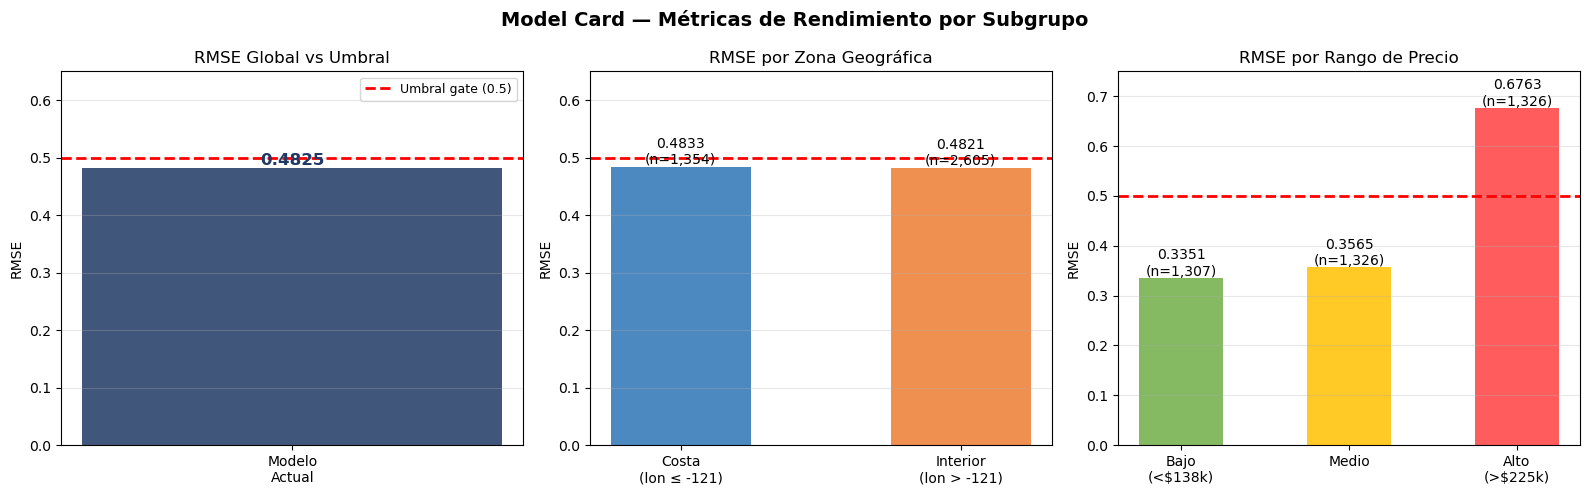

In [7]:
# ── Visualización de métricas ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Card — Métricas de Rendimiento por Subgrupo',
             fontsize=14, fontweight='bold')

C_GLOBAL   = '#1F3864'
C_COSTA    = '#2E75B6'
C_INTERIOR = '#ED7D31'
C_UMBRAL   = '#FF0000'

# ── 1. RMSE global vs umbral ──────────────────────────────────────────────
ax = axes[0]
rmse_val = metricas_globales['rmse']
bar = ax.bar(['Modelo\nActual'], [rmse_val], color=C_GLOBAL, width=0.5, alpha=0.85)
ax.axhline(y=cfg['objetivo']['umbral_aprobacion']['rmse'],
           color=C_UMBRAL, linestyle='--', linewidth=2, label=f'Umbral gate ({cfg["objetivo"]["umbral_aprobacion"]["rmse"]})')
ax.text(0, rmse_val + 0.005, f'{rmse_val:.4f}', ha='center', fontsize=12, fontweight='bold', color=C_GLOBAL)
ax.set_ylabel('RMSE')
ax.set_title('RMSE Global vs Umbral')
ax.set_ylim(0, 0.65)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── 2. RMSE por zona geográfica ───────────────────────────────────────────
ax = axes[1]
zonas = ['Costa\n(lon ≤ -121)', 'Interior\n(lon > -121)']
rmses = [met_costa['rmse'], met_interior['rmse']]
ns    = [met_costa['n'], met_interior['n']]
bars  = ax.bar(zonas, rmses, color=[C_COSTA, C_INTERIOR], alpha=0.85, width=0.5)
ax.axhline(y=cfg['objetivo']['umbral_aprobacion']['rmse'],
           color=C_UMBRAL, linestyle='--', linewidth=2)
for bar, val, n in zip(bars, rmses, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}\n(n={n:,})', ha='center', fontsize=10)
ax.set_ylabel('RMSE')
ax.set_title('RMSE por Zona Geográfica')
ax.set_ylim(0, 0.65)
ax.grid(True, alpha=0.3, axis='y')

# ── 3. RMSE por rango de precio ───────────────────────────────────────────
ax = axes[2]
rangos = [f'Bajo\n(<${q33*100:.0f}k)', 'Medio', f'Alto\n(>${q66*100:.0f}k)']
rmses2 = [met_bajo['rmse'], met_medio['rmse'], met_alto['rmse']]
ns2    = [met_bajo['n'], met_medio['n'], met_alto['n']]
colors = ['#70AD47', '#FFC000', '#FF4040']
bars2  = ax.bar(rangos, rmses2, color=colors, alpha=0.85, width=0.5)
ax.axhline(y=cfg['objetivo']['umbral_aprobacion']['rmse'],
           color=C_UMBRAL, linestyle='--', linewidth=2)
for bar, val, n in zip(bars2, rmses2, ns2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}\n(n={n:,})', ha='center', fontsize=10)
ax.set_ylabel('RMSE')
ax.set_title('RMSE por Rango de Precio')
ax.set_ylim(0, 0.75)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Interpretación — Métricas por Subgrupo

**¿Por qué analizar por subgrupos y no solo el RMSE global?**

El RMSE global puede ocultar rendimiento desigual entre segmentos:

| Subgrupo | Qué revela |
|----------|------------|
| **Costa vs. Interior** | El modelo puede ser más preciso en zonas con más varianza de precios o más datos de entrenamiento. Si el error en el interior es mucho mayor, el modelo no debe usarse para decisiones en esa región. |
| **Rango de precio bajo** | Los bloques económicos suelen tener menos varianza → el modelo tiende a ser más preciso. |
| **Rango de precio alto** | El cap en $500k distorsiona los precios altos. El modelo predice peor en este segmento porque los datos reales están truncados. Es una limitación conocida. |

**Decisión que informa:**  
Si el RMSE en viviendas de precio alto es inaceptable para el negocio,  
puede justificar entrenar un **modelo especializado** para ese segmento,  
o simplemente documentar que el modelo no debe usarse en ese rango.

## 6. Limitaciones y Consideraciones Éticas

Esta sección documenta lo que el modelo **no puede hacer** y los riesgos de usarlo 
fuera de su contexto de diseño. Es la sección más importante para el equipo legal y de cumplimiento.

In [8]:
# ── Sección 5: Limitaciones y ética ──────────────────────────────────────
seccion_limitaciones = {
    'limitaciones_tecnicas': [
        'El modelo opera a nivel de bloque censal, no de vivienda individual. '
        'El error real por vivienda es mayor que el RMSE reportado.',

        'La variable objetivo está capada en $500,000 (MedHouseVal = 5.0). '
        'El modelo subestima sistemáticamente precios superiores a ese umbral.',

        'El modelo no incorpora información temporal. No predice tendencias de mercado '
        'ni el efecto de eventos externos (crisis, regulaciones, pandemias).',

        'Las features de distancia (dist_sacramento, dist_los_angeles) son métricas '
        'euclidianas, no distancias de conducción reales.',
    ],
    'limitaciones_de_datos': [
        'Datos históricos de 1990: los patrones del mercado han cambiado sustancialmente.',
        'Ninguna variable captura calidad de construcción, acceso a servicios o seguridad.',
        'La densidad de datos en zonas rurales es menor → mayor incertidumbre en esas zonas.',
    ],
    'consideraciones_eticas': [
        'El modelo no debe usarse para tomar decisiones de crédito hipotecario ni de alquiler, '
        'ya que puede perpetuar sesgos históricos de segregación residencial presentes en los datos de 1990.',

        'El uso de Latitude/Longitude como features puede actuar como proxy de raza o clase social, '
        'lo que está regulado en muchas jurisdicciones para decisiones de crédito.',

        'Toda predicción debe presentarse con intervalo de incertidumbre, '
        'nunca como un valor exacto de tasación.',
    ],
    'responsable_modelo'  : cfg['proyecto'].get('autor', 'Equipo MLOps'),
    'revision_planificada': 'Revisión semestral o ante detección de drift significativo (PSI > 0.20)',
}

print('=' * 65)
print('  SECCIÓN 5 — LIMITACIONES Y ÉTICA')
print('=' * 65)
print()
print('  LIMITACIONES TÉCNICAS:')
for l in seccion_limitaciones['limitaciones_tecnicas']:
    print(f'  • {l}')
    print()
print('  LIMITACIONES DE DATOS:')
for l in seccion_limitaciones['limitaciones_de_datos']:
    print(f'  • {l}')
print()
print('  CONSIDERACIONES ÉTICAS:')
for l in seccion_limitaciones['consideraciones_eticas']:
    print(f'  ! {l}')
    print()

  SECCIÓN 5 — LIMITACIONES Y ÉTICA

  LIMITACIONES TÉCNICAS:
  • El modelo opera a nivel de bloque censal, no de vivienda individual. El error real por vivienda es mayor que el RMSE reportado.

  • La variable objetivo está capada en $500,000 (MedHouseVal = 5.0). El modelo subestima sistemáticamente precios superiores a ese umbral.

  • El modelo no incorpora información temporal. No predice tendencias de mercado ni el efecto de eventos externos (crisis, regulaciones, pandemias).

  • Las features de distancia (dist_sacramento, dist_los_angeles) son métricas euclidianas, no distancias de conducción reales.

  LIMITACIONES DE DATOS:
  • Datos históricos de 1990: los patrones del mercado han cambiado sustancialmente.
  • Ninguna variable captura calidad de construcción, acceso a servicios o seguridad.
  • La densidad de datos en zonas rurales es menor → mayor incertidumbre en esas zonas.

  CONSIDERACIONES ÉTICAS:
  ! El modelo no debe usarse para tomar decisiones de crédito hipotecario 

## 7. Generación del Model Card

Con todas las secciones definidas, generamos el Model Card en dos formatos:  
- **JSON**: para consumir desde otros sistemas (APIs, dashboards, MLflow)
- **Markdown**: para leer directamente en GitHub o cualquier visor de texto

In [9]:
# ── Ensamblar el Model Card completo ──────────────────────────────────────
model_card = {
    'version_card'    : '1.0',
    'fecha_generacion': datetime.now().isoformat(),
    'descripcion'     : seccion_modelo,
    'uso'             : seccion_uso,
    'datos'           : seccion_datos,
    'metricas'        : seccion_metricas,
    'limitaciones'    : seccion_limitaciones,
}

# ── Guardar JSON ──────────────────────────────────────────────────────────
ruta_json = EXP_DIR / 'model_card.json'
with open(ruta_json, 'w', encoding='utf-8') as f:
    json.dump(model_card, f, indent=2, ensure_ascii=False)

print(f'Model Card JSON guardado en: {ruta_json}')
print(f'Tamaño: {ruta_json.stat().st_size / 1024:.1f} KB')

Model Card JSON guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\model_card.json
Tamaño: 5.6 KB


In [10]:
# ── Generar versión Markdown ──────────────────────────────────────────────
m = seccion_modelo
u = seccion_uso
d = seccion_datos
met = seccion_metricas
lim = seccion_limitaciones

md_lines = [
    f'# Model Card — {m["nombre"]}',
    f'',
    f'**Versión:** {m["version"]}  ',
    f'**Generado:** {m["fecha_generacion"]}  ',
    f'**Responsable:** {lim["responsable_modelo"]}',
    f'',
    f'---',
    f'',
    f'## 1. Descripción',
    f'',
    f'| Campo | Valor |',
    f'|-------|-------|',
    f'| Tipo de problema | {m["tipo_problema"]} |',
    f'| Algoritmo | {m["clase_python"]} |',
    f'| N° de features | {m["n_features"]} (8 originales + 5 derivadas) |',
    f'| Descripción | {m["descripcion"]} |',
    f'| Objetivo de negocio | {m["objetivo_negocio"]} |',
    f'',
    f'**Hiperparámetros:** `{m["hiperparametros"]}`',
    f'',
    f'---',
    f'',
    f'## 2. Uso Previsto',
    f'',
    f'### Usos aceptados',
]
for uso in u['uso_previsto']:
    md_lines.append(f'- {uso}')
md_lines += [
    f'',
    f'### Fuera de alcance',
]
for uso in u['fuera_de_alcance']:
    md_lines.append(f'- **NO usar para:** {uso}')
md_lines += [
    f'',
    f'---',
    f'',
    f'## 3. Datos de Entrenamiento',
    f'',
    f'| Campo | Valor |',
    f'|-------|-------|',
    f'| Fuente | `{d["fuente"]}` |',
    f'| Filas originales | {d["n_filas_originales"]:,} |',
    f'| Filas de entrenamiento | {d["n_filas_train"]:,} |',
    f'| Filas de test | {d["n_filas_test"]:,} |',
    f'| Split test | {int(d["proporcion_test"]*100)}% |',
    f'| Semilla | {d["semilla"]} (reproducible) |',
    f'',
    f'**Sesgos conocidos:**',
]
for s in d['sesgos_conocidos']:
    md_lines.append(f'- {s}')
md_lines += [
    f'',
    f'---',
    f'',
    f'## 4. Métricas de Rendimiento',
    f'',
    f'### Global',
    f'',
    f'| Métrica | Valor | Umbral | Estado |',
    f'|---------|-------|--------|--------|',
    f'| RMSE | {met["metricas_globales"]["rmse"]:.4f} | < {met["umbrales_gate"]["rmse"]} | {"APROBADO" if met["aprobado_gate"] else "RECHAZADO"} |',
    f'| MAE  | {met["metricas_globales"]["mae"]:.4f}  | — | — |',
    f'| R²   | {met["metricas_globales"]["r2"]:.4f}   | > {met["umbrales_gate"]["r2"]} | {"APROBADO" if met["aprobado_gate"] else "RECHAZADO"} |',
    f'',
    f'### Por zona geográfica',
    f'',
    f'| Zona | N | RMSE | MAE | R² |',
    f'|------|---|------|-----|-----|',
    f'| Costa (lon ≤ -121) | {met["por_zona"]["costa"]["n"]:,} | {met["por_zona"]["costa"]["rmse"]:.4f} | {met["por_zona"]["costa"]["mae"]:.4f} | {met["por_zona"]["costa"]["r2"]:.4f} |',
    f'| Interior (lon > -121) | {met["por_zona"]["interior"]["n"]:,} | {met["por_zona"]["interior"]["rmse"]:.4f} | {met["por_zona"]["interior"]["mae"]:.4f} | {met["por_zona"]["interior"]["r2"]:.4f} |',
    f'',
    f'---',
    f'',
    f'## 5. Limitaciones y Ética',
    f'',
    f'### Limitaciones técnicas',
]
for l in lim['limitaciones_tecnicas']:
    md_lines.append(f'- {l}')
md_lines += [
    f'',
    f'### Consideraciones éticas',
]
for l in lim['consideraciones_eticas']:
    md_lines.append(f'- **AVISO:** {l}')
md_lines += [
    f'',
    f'---',
    f'',
    f'*Revisión planificada: {lim["revision_planificada"]}*',
    f'',
    f'*Generado automáticamente por el pipeline MLOps — `notebooks/12_model_card.ipynb`*',
]

ruta_md = EXP_DIR / 'model_card.md'
with open(ruta_md, 'w', encoding='utf-8') as f:
    f.write('\n'.join(md_lines))

print(f'Model Card Markdown guardado en: {ruta_md}')
print(f'Tamaño: {ruta_md.stat().st_size / 1024:.1f} KB')
print()
print('Vista previa (primeras 30 líneas):')
print('-' * 60)
print('\n'.join(md_lines[:30]))

Model Card Markdown guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\model_card.md
Tamaño: 3.7 KB

Vista previa (primeras 30 líneas):
------------------------------------------------------------
# Model Card — prediccion-precio-viviendas

**Versión:** 1.0.0  
**Generado:** 2026-03-18 10:17:03  
**Responsable:** Equipo MLOps

---

## 1. Descripción

| Campo | Valor |
|-------|-------|
| Tipo de problema | regresion |
| Algoritmo | GradientBoostingRegressor |
| N° de features | 13 (8 originales + 5 derivadas) |
| Descripción | Predecir el precio mediano de viviendas en California |
| Objetivo de negocio | Estimar el precio de vivienda para apoyar decisiones de inversiÃ³n |

**Hiperparámetros:** `{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'random_state': 42, 'subsample': 1.0}`

---

## 2. Uso Previsto

### Usos aceptados
- Estimación orientativa del precio de vivienda para análisis de mercado
- Apoyo a decisiones de inversión inmobiliaria (no dec

## 8. Conclusiones

### ¿Qué aporta el Model Card al ciclo MLOps?

| Sin Model Card | Con Model Card |
|---------------|----------------|
| El equipo de negocio no sabe qué limitaciones tiene el modelo | Las limitaciones están documentadas y accesibles |
| Los auditores no pueden verificar con qué datos fue entrenado | El origen, preprocesamiento y sesgos están registrados |
| El modelo se usa en casos para los que no fue diseñado | Los usos fuera de alcance están explícitamente prohibidos |
| Si el modelo cambia, nadie sabe qué era la versión anterior | Cada versión genera su propio Model Card con timestamp |

### Posición en el ciclo MLOps

```
NB05 Evaluación   → métricas de rendimiento
      +
NB07 Monitoreo    → estado en producción
      +
NB08 AutoML       → versión del modelo
      |
      v
NB12 Model Card   → documento automático de gobernanza
      |
      v
Reguladores / Auditores / Equipo de negocio
```

### Buenas prácticas
- **Regenerar el Model Card con cada nueva versión del modelo** — nunca editarlo a mano
- **Versionarlo junto al modelo** en MLflow o el Model Registry
- **Incluir métricas por subgrupo** — el RMSE global no es suficiente
- **Revisar la sección de ética** con el equipo legal antes de desplegar en producción
- El formato Markdown permite renderizarlo directamente en GitHub, Confluence o Notion